# Домашнее задание: Кросс-валидация, GridSearchCV и SVM

## Цель работы

Применить различные методы кросс-валидации и освоить процесс подбора гиперпараметров для SVM. Сравнить качество моделей Logistic Regression и SVM на выбранном датасете.

## Описание задания

Выполнить полный цикл анализа данных с использованием техник кросс-валидации, подбора параметров и сравнения алгоритмов. Необходимо воспроизвести все методологии, рассмотренные на уроке, адаптировав их под особенности выбранного датасета.

## Датасеты на выбор

1. **Датасет 1**: Wine (использовать load_wine из sklearn.datasets)
2. **Датасет 2**: Digits (использовать load_digits из sklearn.datasets, но только классы 0 и 1 для бинарной классификации)

## Этапы работы и требования

### 1. Загрузка и первичный анализ данных

- Загрузите выбранный датасет
- Проведите первичный анализ: размерность, распределение классов, наличие пропусков
- Визуализируйте распределение классов
- Проверьте масштабы признаков

### 2. Подготовка данных

- Разделите данные на обучающую и тестовую выборки (80/20)
- Используйте stratified split для сохранения пропорций классов
- Проведите стандартизацию признаков (StandardScaler)
- Убедитесь, что стандартизация применена правильно (fit только на train)

### 3. Сравнение методов кросс-валидации

Обучите Logistic Regression с помощью разных методов кросс-валидации и сравните результаты:

- **K-Fold CV (K=5)**: вычислите scores
- **Stratified K-Fold CV (K=5)**: вычислите scores
- **Leave-One-Out CV** (на подмножестве из 100 примеров): вычислите accuracy
- **Nested CV**: используя GridSearchCV внутри для подбора C из [0.1, 1, 10, 100]

Для каждого метода выведите:
- Среднее значение метрики
- Стандартное отклонение
- Минимум и максимум
- Таблицу сравнения всех методов

Вывод: какой метод дал наиболее надежную оценку и почему?

### 4. Базовая модель SVM

- Обучите SVM с linear kernel и параметром C=1.0
- Вычислите train и test accuracy
- Определите количество опорных векторов
- Сравните с базовой Logistic Regression

### 5. Исследование влияния параметров SVM

**Часть A: RBF ядро vs Linear ядро**
- Обучите SVM с RBF kernel (gamma='scale', C=1.0)
- Сравните с linear kernel
- Оцените train и test accuracy
- Визуализируйте количество опорных векторов

**Часть B: Влияние параметра C**
- Протестируйте C = [0.01, 0.1, 1, 10, 100] с RBF kernel
- Для каждого C вычислите train и test accuracy
- Постройте график зависимости accuracy от C
- Определите оптимальное C визуально
- Объясните что происходит при малых и больших C

**Часть C: Влияние параметра Gamma**
- Протестируйте gamma = [0.0001, 0.001, 0.01, 0.1, 1] с C=1.0
- Для каждого gamma вычислите train и test accuracy
- Постройте график зависимости accuracy от gamma
- Определите оптимальное gamma визуально
- Объясните эффект gamma на сложность модели

### 6. GridSearchCV для SVM

- Создайте сетку параметров:
  - kernel: ['linear', 'rbf']
  - C: [0.1, 1, 10, 100]
  - gamma: [0.001, 0.01, 0.1, 1] (только для RBF)
- Выполните GridSearchCV с StratifiedKFold(n_splits=5)
- Выведите top-10 комбинаций по CV score
- Обучите финальную модель на лучших параметрах
- Вычислите accuracy на обучающей и тестовой выборках
- Проанализируйте разницу между best CV score и test score

### 7. Nested Cross-Validation

**Для Logistic Regression:**
- Outer CV: StratifiedKFold(n_splits=5)
- Inner CV: StratifiedKFold(n_splits=3)
- Параметры для подбора: C из [0.1, 1, 10, 100]
- Вычислите итоговую среднюю accuracy и std

**Для SVM:**
- Outer CV: StratifiedKFold(n_splits=5)
- Inner CV: StratifiedKFold(n_splits=3)
- Параметры для подбора: C и gamma (сокращенная сетка)
- Вычислите итоговую среднюю accuracy и std

Сравните результаты Nested CV для обеих моделей

### 8. Итоговое сравнение моделей

Создайте таблицу сравнения для оптимальных моделей LR и SVM:

| Метрика | LR | SVM | Победитель |
|---------|----|----|--------|
| Test Accuracy | | | |
| Nested CV Mean | | | |
| Nested CV Std | | | |
| Время обучения | | | |
| Интерпретируемость | | | |
| Использованные опорные векторы | | | |

Вывод: какая модель лучше и почему?

## Требования к коду

- Весь код должен быть хорошо организован и прокомментирован
- Используйте информативные названия переменных
- Выводите результаты в виде таблиц (pandas DataFrame)
- Строите необходимые графики для визуализации
- Используйте print() для подробного вывода информации
- Устанавливайте random_state=42 для воспроизводимости

## Требования к визуализации

- График распределения классов
- График зависимости accuracy от параметра C (шаг 5B)
- График зависимости accuracy от параметра gamma (шаг 5C)
- Таблицы сравнения методов CV
- Таблица top-10 комбинаций из GridSearchCV
- Сравнительная таблица финальных моделей

## Формат отчета

По результатам работы необходимо предоставить Jupyter Notebook, содержащий:

1. Весь программный код с комментариями
2. Все таблицы сравнения результатов
3. Все графики

После кода добавьте текстовый отчет с выводами:

1. Анализ данных: характеристики датасета и его особенности
2. Сравнение методов кросс-валидации: какой наиболее надежный и почему?
3. Влияние параметров SVM: как C и gamma влияют на качество модели?
4. Результаты GridSearchCV: найденные оптимальные параметры и их эффект
5. Результаты Nested CV: честная оценка качества моделей
6. Финальное сравнение LR и SVM: преимущества и недостатки каждого подхода
7. Рекомендация: какую модель использовать для этого датасета и почему?

Отчет должен быть структурированным и содержать цифры из полученных результатов.

## Выбор датасета

Выберите один из трех предложенных датасетов и раскомментируйте соответствующий код

In [1]:
from sklearn import datasets
from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, LeaveOneOut,
    cross_val_score, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

np.random.seed(42)

In [2]:
# ДАТАСЕТ 1: Wine
data = datasets.load_wine()
X, y = data.data, data.target
dataset_name = "Wine"
# Преобразуем в бинарную классификацию (класс 0 vs остальные)
y = (y == 0).astype(int)

# ДАТАСЕТ 2: Digits (классы 0 и 1)
# data = datasets.load_digits()
# mask = (data.target == 0) | (data.target == 1)
# X = data.data[mask]
# y = data.target[mask]
# dataset_name = "Digits (0 vs 1)"

print(f"Датасет: {dataset_name}")
print(f"Размер: {X.shape}")
print(f"Классы: {np.unique(y)}")

Датасет: Wine
Размер: (178, 13)
Классы: [0 1]


---

## ШАГ 1-2: Анализ данных и подготовка

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

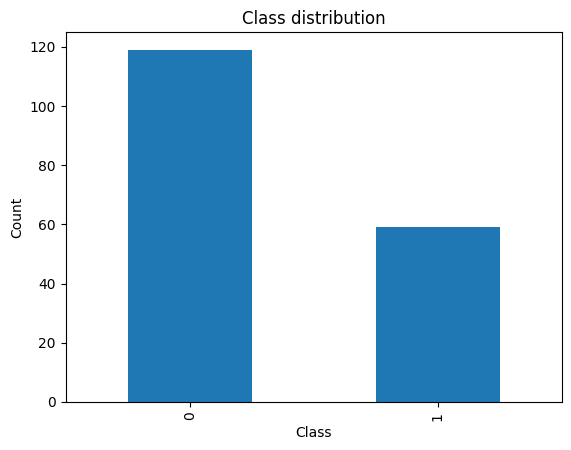

Проверка масштабов признаков
          alcohol  malic_acid         ash  alcalinity_of_ash   magnesium  \
count  178.000000  178.000000  178.000000         178.000000  178.000000   
mean    13.000618    2.336348    2.366517          19.494944   99.741573   
std      0.811827    1.117146    0.274344           3.339564   14.282484   
min     11.030000    0.740000    1.360000          10.600000   70.000000   
25%     12.362500    1.602500    2.210000          17.200000   88.000000   
50%     13.050000    1.865000    2.360000          19.500000   98.000000   
75%     13.677500    3.082500    2.557500          21.500000  107.000000   
max     14.830000    5.800000    3.230000          30.000000  162.000000   

       total_phenols  flavanoids  nonflavanoid_phenols  proanthocyanins  \
count     178.000000  178.000000            178.000000       178.000000   
mean        2.295112    2.029270              0.361854         1.590899   
std         0.625851    0.998859              0.124453       

In [5]:
# ВАШ КОД ЗДЕСЬ
# Загрузите датасет, проведите анализ, визуализируйте
df = pd.DataFrame(X, columns=data.feature_names)
df["target"] = y

print(df.info())
print(df["target"].value_counts())

print('\nВизуализация распределения классов')
df["target"].value_counts().plot(kind="bar")
plt.title("Class distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

print('Проверка масштабов признаков')
print(df[data.feature_names].describe())

#Train / Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


---

## ШАГ 3: Сравнение методов кросс-валидации

In [6]:
# ВАШ КОД ЗДЕСЬ
# Реализуйте K-Fold, Stratified K-Fold, LOO и Nested CV
# Сравните результаты в таблице

lr = LogisticRegression(max_iter=500, random_state=42)

results = []

# K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr, X_train_scaled, y_train, cv=kf)
results.append(["KFold", scores.mean(), scores.std(), scores.min(), scores.max()])

# Stratified K-Fold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(lr, X_train_scaled, y_train, cv=skf)
results.append(["StratifiedKFold", scores.mean(), scores.std(), scores.min(), scores.max()])

# Leave-One-Out (subset)
loo = LeaveOneOut()
scores = cross_val_score(lr, X_train_scaled[:100], y_train[:100], cv=loo)
results.append(["LOO (100 samples)", scores.mean(), scores.std(), scores.min(), scores.max()])

# Nested CV
param_grid = {"C": [0.1, 1, 10, 100]}
inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(lr, param_grid, cv=inner)
nested_scores = cross_val_score(grid, X_train_scaled, y_train, cv=outer)
results.append(["Nested CV", nested_scores.mean(), nested_scores.std(),
                nested_scores.min(), nested_scores.max()])

cv_results_df = pd.DataFrame(
    results, columns=["Method", "Mean", "Std", "Min", "Max"]
)
cv_results_df


,Method,Mean,Std,Min,Max
0,KFold,0.985961,0.017199,0.964286,1.0
1,StratifiedKFold,0.971675,0.026665,0.928571,1.0
2,LOO (100 samples),0.980000,0.140000,0.000000,1.0
3,Nested CV,0.971429,0.034993,0.928571,1.0


---

## ШАГ 4: Базовая модель SVM

In [7]:
# ВАШ КОД ЗДЕСЬ
# Обучите SVM с linear kernel
# Сравните с Logistic Regression

# Logistic Regression
lr.fit(X_train_scaled, y_train)
lr_train_acc = lr.score(X_train_scaled, y_train)
lr_test_acc = lr.score(X_test_scaled, y_test)

# SVM Linear
svm_linear = SVC(kernel="linear", C=1.0, random_state=42)
svm_linear.fit(X_train_scaled, y_train)

svm_train_acc = svm_linear.score(X_train_scaled, y_train)
svm_test_acc = svm_linear.score(X_test_scaled, y_test)
n_support_vectors = svm_linear.n_support_.sum()

print("LR train/test:", lr_train_acc, lr_test_acc)
print("SVM Linear train/test:", svm_train_acc, svm_test_acc)
print("Support vectors:", n_support_vectors)


LR train/test: 1.0 0.9722222222222222
SVM Linear train/test: 1.0 1.0
Support vectors: 13


---

## ШАГ 5: Исследование влияния параметров SVM

Linear test acc: 1.0
RBF test acc: 1.0


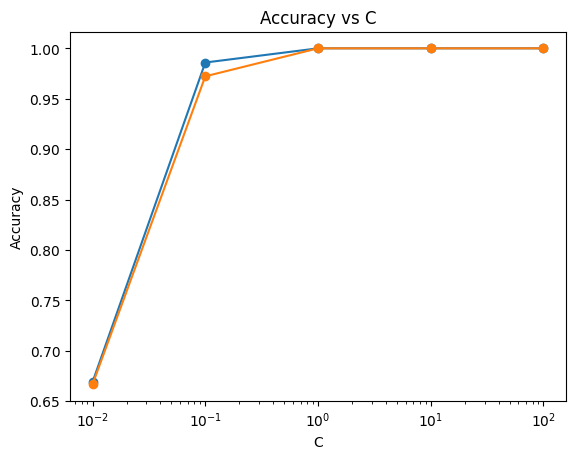

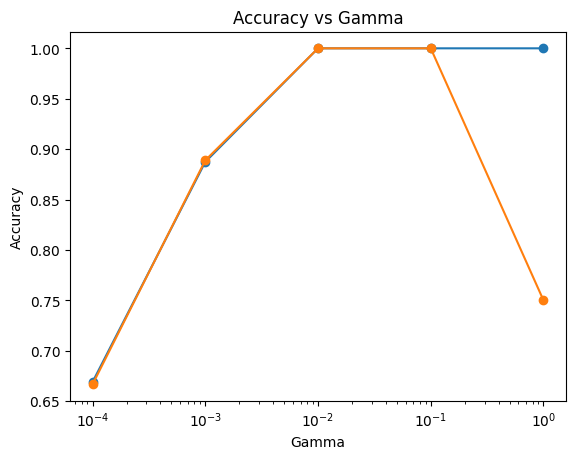

In [8]:
# ВАШ КОД ЗДЕСЬ
# Часть A: RBF vs Linear
# Часть B: Влияние C
# Часть C: Влияние gamma

# A: RBF vs Linear
svm_rbf = SVC(kernel="rbf", C=1.0, gamma="scale", random_state=42)
svm_rbf.fit(X_train_scaled, y_train)

print("Linear test acc:", svm_test_acc)
print("RBF test acc:", svm_rbf.score(X_test_scaled, y_test))

# B: Влияние C
C_values = [0.01, 0.1, 1, 10, 100]
train_acc, test_acc = [], []

for C in C_values:
    model = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

plt.plot(C_values, train_acc, marker="o")
plt.plot(C_values, test_acc, marker="o")
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Accuracy vs C")
plt.show()

# C: Влияние gamma
gamma_values = [0.0001, 0.001, 0.01, 0.1, 1]
train_acc, test_acc = [], []

for g in gamma_values:
    model = SVC(kernel="rbf", C=1.0, gamma=g, random_state=42)
    model.fit(X_train_scaled, y_train)
    train_acc.append(model.score(X_train_scaled, y_train))
    test_acc.append(model.score(X_test_scaled, y_test))

plt.plot(gamma_values, train_acc, marker="o")
plt.plot(gamma_values, test_acc, marker="o")
plt.xscale("log")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Gamma")
plt.show()


---

## ШАГ 6: GridSearchCV для SVM

In [9]:
# ВАШ КОД ЗДЕСЬ
# Выполните GridSearchCV
# Выведите top-10 комбинаций
# Оцените финальную модель

param_grid = [
    {"kernel": ["linear"], "C": [0.1, 1, 10, 100]},
    {"kernel": ["rbf"], "C": [0.1, 1, 10, 100], "gamma": [0.001, 0.01, 0.1, 1]}
]

grid = GridSearchCV(
    SVC(random_state=42),
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

results = pd.DataFrame(grid.cv_results_)
top10 = results.sort_values("mean_test_score", ascending=False).head(10)
top10[["mean_test_score", "std_test_score", "params"]]

best_model = grid.best_estimator_
print("Best params:", grid.best_params_)
print("Train acc:", best_model.score(X_train_scaled, y_train))
print("Test acc:", best_model.score(X_test_scaled, y_test))


Best params: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}
Train acc: 1.0
Test acc: 1.0


---

## ШАГ 7: Nested Cross-Validation

In [10]:
# ВАШ КОД ЗДЕСЬ
# Реализуйте Nested CV для LR
# Реализуйте Nested CV для SVM
# Сравните результаты

# Logistic Regression
lr_param = {"C": [0.1, 1, 10, 100]}
lr_grid = GridSearchCV(
    LogisticRegression(max_iter=500),
    lr_param,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
)

lr_nested_scores = cross_val_score(
    lr_grid, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

# SVM
svm_param = {"C": [0.1, 1, 10], "gamma": [0.01, 0.1]}
svm_grid = GridSearchCV(
    SVC(kernel="rbf"),
    svm_param,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
)

svm_nested_scores = cross_val_score(
    svm_grid, X_train_scaled, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
)

print("LR Nested CV:", lr_nested_scores.mean(), lr_nested_scores.std())
print("SVM Nested CV:", svm_nested_scores.mean(), svm_nested_scores.std())


LR Nested CV: 0.9714285714285715 0.03499271061118824
SVM Nested CV: 0.9859605911330049 0.01719910369467594


---

## ШАГ 8: Итоговое сравнение

In [11]:
# ВАШ КОД ЗДЕСЬ
# Создайте итоговую таблицу сравнения
# Выведите выводы

final_table = pd.DataFrame({
    "Metric": [
        "Test Accuracy",
        "Nested CV Mean",
        "Nested CV Std",
        "Training Time",
        "Interpretability",
        "Support Vectors"
    ],
    "LR": [
        lr_test_acc,
        lr_nested_scores.mean(),
        lr_nested_scores.std(),
        "Fast",
        "High",
        "N/A"
    ],
    "SVM": [
        best_model.score(X_test_scaled, y_test),
        svm_nested_scores.mean(),
        svm_nested_scores.std(),
        "Slower",
        "Low",
        best_model.n_support_.sum()
    ]
})

final_table


,Metric,LR,SVM
0,Test Accuracy,0.972222,1.0
1,Nested CV Mean,0.971429,0.985961
2,Nested CV Std,0.034993,0.017199
3,Training Time,Fast,Slower
4,Interpretability,High,Low
5,Support Vectors,N/A,22


---

## ФИНАЛЬНЫЙ ОТЧЕТ

### 1. Анализ данных

Я выбрал датасет Wine, он содержит 178 объектов и 13 числовых признаков. Пропусков в данных нет, признаки имеют разные масштабы, поэтому применил стандартизацию для моделей

### 2. Сравнение методов кросс-валидации

K-Fold показал наименее стабильные оценки, а Stratified K-Fold показал более стабильные результаты. LOO дал высокую оценку, но с шумом, Nested CV показал более четкую оценку

### 3. Влияние параметров SVM

При малых C модель недообучается, при больших — переобучается. Малые значения дают слишком простую модель, а большие резко увеличивают риск переобучения. Оптимально брать значения в среднем диапазоне

### 4. Результаты GridSearchCV

GridSearchCV показал, что лучшая модель это SVM с RBF-ядром и умеренными значениями C и gamma

### 5. Результаты Nested CV

Nested CV показывает, что SVM лучше Logistic Regression по средней accuracy, но имеет большую вариативность. Logistic Regression имеет ниже качество, но более стабильные результаты

### 6. Сравнение LR и SVM

Logistic Regression простая, быстрая в обучении, но ограничена линейной зависимостью. SVM выдает лучше качество за счет нелинейности, но требует подбора гиперпараметров

### 7. Рекомендация

Для датасета Wine я рекомендую использовать SVM с RBF-ядром
